<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/DBSCAN_un.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!
Shape: (62423, 3)

First 5 Rows:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Genre Features:
   (no genres listed)  Action  Adventure  Animation  Children  Comedy  Crime  \
0                   0       0          1          1         1       1      0   
1                   0       0          1          0         1       0      0   
2                   0       0          0          0         0       1      0   
3     

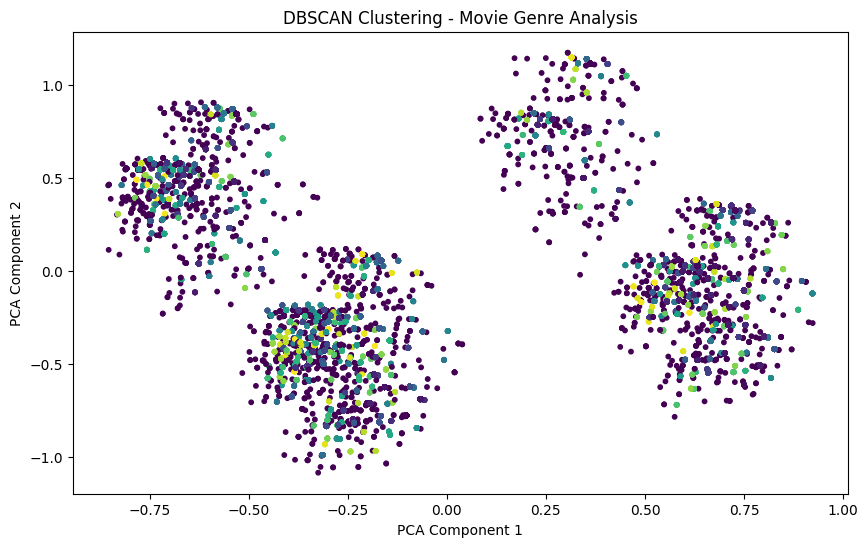


Silhouette Score: 1.0

Sample Movies from Each Cluster:

Cluster -1:
                                                          title                                   genres
City of Lost Children, The (Cité des enfants perdus, La) (1995)   Adventure|Drama|Fantasy|Mystery|Sci-Fi
                                        Wings of Courage (1995)                   Adventure|Romance|IMAX
                                              Pocahontas (1995) Animation|Children|Drama|Musical|Romance
                                           Bottle Rocket (1996)           Adventure|Comedy|Crime|Romance
                                  Muppet Treasure Island (1996)        Adventure|Children|Comedy|Musical

Cluster 0:
                                         title                                      genres
                              Toy Story (1995) Adventure|Animation|Children|Comedy|Fantasy
                                   Antz (1998) Adventure|Animation|Children|Comedy|Fantasy
               

In [7]:
# ============================================
# DBSCAN CLUSTERING - MOVIES DATASET
# Unsupervised Machine Learning
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("movies.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ============================================
# 2. HANDLE MISSING VALUES
# ============================================

df["genres"] = df["genres"].fillna("Unknown")

# ============================================
# 3. CONVERT GENRES INTO FEATURES
# ============================================

# Convert:
# Adventure|Animation|Comedy
# into separate genre columns

genre_list = df["genres"].str.split("|")

mlb = MultiLabelBinarizer()

genre_features = mlb.fit_transform(genre_list)

genre_df = pd.DataFrame(
    genre_features,
    columns=mlb.classes_
)

print("\nGenre Features:")
print(genre_df.head())

# ============================================
# 4. APPLY DBSCAN
# ============================================

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

clusters = dbscan.fit_predict(genre_df)

# Add cluster labels

df["Cluster"] = clusters

# ============================================
# 5. DISPLAY RESULTS
# ============================================

print("\nClustered Movies:")

print(
    df[
        ["movieId", "title", "genres", "Cluster"]
    ].head(20)
)

# ============================================
# 6. COUNT CLUSTERS
# ============================================

cluster_counts = df["Cluster"].value_counts()

print("\nCluster Counts:")
print(cluster_counts)

# ============================================
# 7. FIND NUMBER OF CLUSTERS
# ============================================

number_of_clusters = len(
    set(clusters)
) - (1 if -1 in clusters else 0)

print(
    "\nNumber of Clusters:",
    number_of_clusters
)

# ============================================
# 8. FIND NOISE POINTS
# ============================================

noise_count = list(clusters).count(-1)

print(
    "Number of Noise Points:",
    noise_count
)

# ============================================
# 9. PCA FOR VISUALIZATION
# ============================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(genre_df)

# ============================================
# 10. VISUALIZE DBSCAN CLUSTERS
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=10
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "DBSCAN Clustering - Movie Genre Analysis"
)

plt.show()

# ============================================
# 11. SILHOUETTE SCORE
# ============================================

# Silhouette score requires at least
# 2 clusters excluding noise

non_noise = clusters != -1

if (
    number_of_clusters >= 2
    and sum(non_noise) > number_of_clusters
):

    score = silhouette_score(
        genre_df[non_noise],
        clusters[non_noise]
    )

    print(
        "\nSilhouette Score:",
        round(score, 4)
    )

else:

    print(
        "\nSilhouette Score cannot be calculated."
    )

# ============================================
# 12. SAMPLE CLUSTER ANALYSIS
# ============================================

print("\nSample Movies from Each Cluster:")

for cluster in sorted(
    df["Cluster"].unique()
):

    print(
        f"\nCluster {cluster}:"
    )

    print(
        df[
            df["Cluster"] == cluster
        ][
            ["title", "genres"]
        ].head(5).to_string(index=False)
    )

# ============================================
# 13. FINAL OUTPUT
# ============================================

print("\n====================================")
print("DBSCAN CLUSTERING COMPLETED")
print("====================================")

print(
    "Total Movies:",
    len(df)
)

print(
    "Clusters Found:",
    number_of_clusters
)

print(
    "Noise Points:",
    noise_count
)